In [ ]:
import numpy as np
import plotly.graph_objects as go
from scipy.optimize import fsolve

Просимулируем физику 4 методами

In [ ]:
# Параметры системы
m, g = 1.0, 9.81
k1, k2 = 50.0, 50.0
L01, L02 = 0.5, 0.5
mu = np.radians(80)
Lw, Lf = 1.0, 1.0
anchor1 = np.array([Lw * np.cos(mu), Lw * np.sin(mu)])
anchor2 = np.array([Lf, 0.0])

def get_acceleration(pos):
    r1, r2 = pos - anchor1, pos - anchor2
    dist1, dist2 = np.linalg.norm(r1), np.linalg.norm(r2)
    f1 = -k1 * (dist1 - L01) * (r1 / dist1)
    f2 = -k2 * (dist2 - L02) * (r2 / dist2)
    return (f1 + f2 + np.array([0, -m * g])) / m

dt, steps = 0.01, 1000
p0, v0 = np.array([0.475, 0.285]), np.array([0.0, 0.0])
method_names = ["Explicit Euler", "Implicit Euler", "Symplectic Euler", "Vanilla Verlet"]

pos_data = {name: np.zeros((steps, 2)) for name in method_names}
vel_data = {name: np.zeros((steps, 2)) for name in method_names}

for name in method_names:
    pos_data[name][0], vel_data[name][0] = p0, v0

for i in range(steps - 1):
    # Explicit
    a_exp = get_acceleration(pos_data["Explicit Euler"][i])
    pos_data["Explicit Euler"][i+1] = pos_data["Explicit Euler"][i] + vel_data["Explicit Euler"][i] * dt
    vel_data["Explicit Euler"][i+1] = vel_data["Explicit Euler"][i] + a_exp * dt
    # Implicit
    def impl_func(x):
        p, v = x[:2], x[2:]
        return np.concatenate([p - pos_data["Implicit Euler"][i] - v*dt, v - vel_data["Implicit Euler"][i] - get_acceleration(p)*dt])
    sol = fsolve(impl_func, np.concatenate([pos_data["Implicit Euler"][i], vel_data["Implicit Euler"][i]]))
    pos_data["Implicit Euler"][i+1], vel_data["Implicit Euler"][i+1] = sol[:2], sol[2:]
    # Symplectic
    a_s = get_acceleration(pos_data["Symplectic Euler"][i])
    vel_data["Symplectic Euler"][i+1] = vel_data["Symplectic Euler"][i] + a_s * dt
    pos_data["Symplectic Euler"][i+1] = pos_data["Symplectic Euler"][i] + vel_data["Symplectic Euler"][i+1] * dt
    # Verlet
    pc = pos_data["Vanilla Verlet"][i]
    ac = get_acceleration(pc)
    pp = pos_data["Vanilla Verlet"][i-1] if i > 0 else pc - v0*dt + 0.5*ac*dt**2
    pos_data["Vanilla Verlet"][i+1] = 2*pc - pp + ac*dt**2

# PАСЧЕТ ЭНЕРГИИ
def get_total_energy(pos, vel):
    e_kin = 0.5 * m * np.sum(vel**2)
    dist1 = np.linalg.norm(pos - anchor1)
    dist2 = np.linalg.norm(pos - anchor2)
    e_pot_spring = 0.5 * k1 * (dist1 - L01)**2 + 0.5 * k2 * (dist2 - L02)**2
    e_pot_grav = m * g * pos[1]
    return e_kin + e_pot_spring + e_pot_grav

energy_data = {name: np.zeros(steps) for name in method_names}
for name in method_names:
    for i in range(steps):
        energy_data[name][i] = get_total_energy(pos_data[name][i], vel_data[name][i])



Визуализируем траектории и энергии:

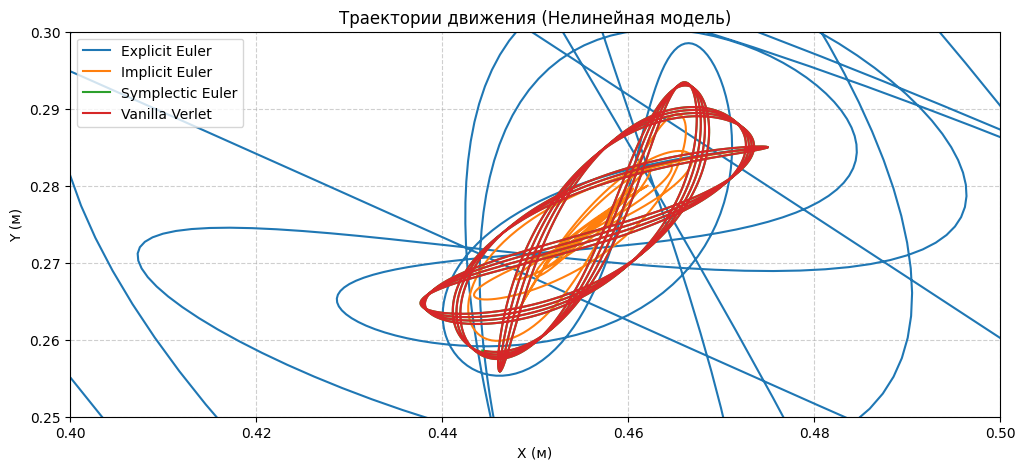

In [ ]:
import matplotlib.pyplot as plt
# ВИЗУАЛИЗАЦИЯ ТРАЕКТОРИЙ
plt.figure(figsize=(12, 5))

for name in method_names:
    plt.plot(pos_data[name][:, 0], pos_data[name][:, 1], label=name, lw=1.5)

plt.title("Траектории движения (Нелинейная модель)")
plt.xlabel("X (м)")
plt.ylabel("Y (м)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(0.4, 0.5)
plt.ylim(0.25, 0.3)

plt.show()

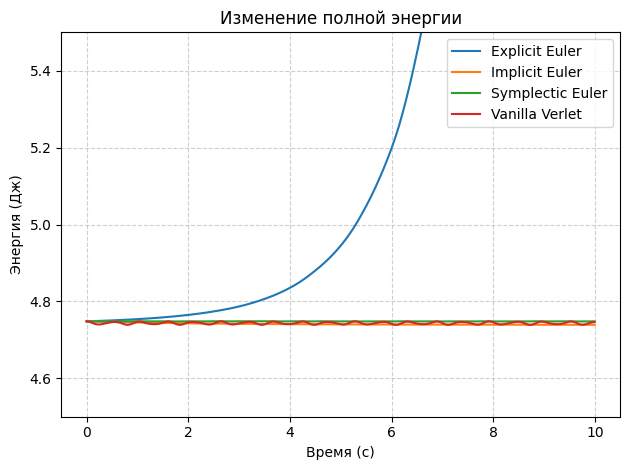

In [ ]:
# ВИЗУАЛИЗАЦИЯ ЭНЕРГИИ
time_axis = np.arange(steps) * dt
for name in method_names:
    plt.plot(time_axis, energy_data[name], label=name)

plt.title("Изменение полной энергии")
plt.xlabel("Время (с)")
plt.ylabel("Энергия (Дж)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(4.5, 5.5)

plt.tight_layout()
plt.show()

Видно по графикам траектории, что явный Эйлер улетает, а неявный наоборот теряет энергию, это же наблюдается и на графике с энергией. Можно посмотреть по ближе на неявного Эйлера и убедиться, что энергия там теряется.

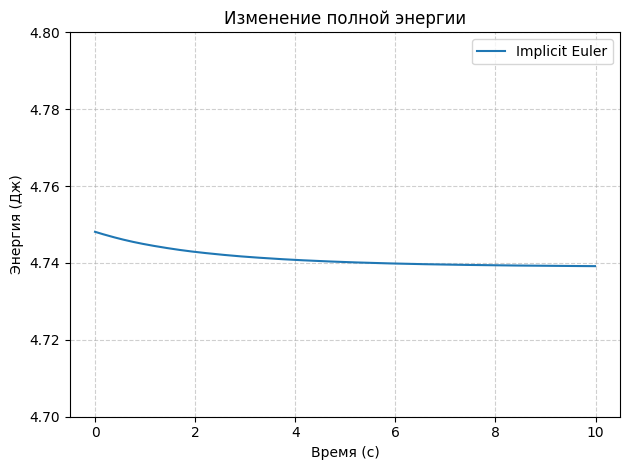

In [ ]:
plt.plot(time_axis, energy_data["Implicit Euler"], label="Implicit Euler")

plt.title("Изменение полной энергии")
plt.xlabel("Время (с)")
plt.ylabel("Энергия (Дж)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(4.7, 4.8)

plt.tight_layout()
plt.show()